## Project overview
 There ia a project from video streaming company. This company recently lossing more customers. The stakeholders have decided to use data science to khow the reason and figure out the solution.

## 1. Define Scope of the project
#### Problem statement:
A video streming company is experiencing a decline in premium subscription, with significant number of customers canceling their subscription plans. The goal is to understand the factors contributing customers churn and develop strategies.

#### Objective and Goals
Analyze customer behaviour and usage pattern to identify main factors contributing customers churn

#### Data requirements
Gender and demographic = Age, sex, location
Usage = How much time they have spent, what are they search, how much time they spent on each video, how many times they open the app in a day (daily active users)
Subscription plan: How frequent they purchase the plan, how many times they come to the subscription landing page
Engagement with add-ons

In [2]:
# import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv(".//Streaming.csv")
df.sample(5)

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
2186,CUST002187,38.0,Male,15,West,Credit Card,4,2.0,9.04,288,28.91,1
542,CUST000543,NaN,Female,26,South,Credit Card,2,3.0,15.07,54,40.40,1
1262,CUST001263,57.0,Male,12,North,Credit Card,1,7.0,13.34,349,46.07,1
1923,CUST001924,29.0,Male,35,North,Debit Card,1,7.0,14.26,252,53.92,0
3135,CUST003136,35.0,Male,59,South,Debit Card,2,9.0,6.23,271,59.54,0


### Remove the features from dataset which are not important

In [4]:
df.drop(columns=['Subscription_Length','Payment_Method'], inplace=True)
df.sample(5)

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
4687,CUST004688,51.0,Male,East,0,3.0,11.13,209,39.02,1
3953,CUST003954,NaN,Female,South,1,6.0,5.66,116,53.05,0
381,CUST000382,NaN,Male,West,2,4.0,16.56,215,50.47,0
1633,CUST001634,24.0,Female,East,1,2.0,6.29,15,40.35,1
4862,CUST004863,35.0,Female,East,2,8.0,5.46,28,57.63,0


### Undersatnd the features datatypes

In [5]:
df.dtypes

Customer_ID                   str
Age                       float64
Gender                        str
Region                        str
Support_Tickets_Raised      int64
Satisfaction_Score        float64
Discount_Offered          float64
Last_Activity               int64
Monthly_Spend             float64
Churned                     int64
dtype: object

1). Change datatype 62-bit to 32-bit where is possible because it consume less resources

## Make decision remove or impute missing values

In [6]:
df.isna().sum()

Customer_ID                 0
Age                       500
Gender                      0
Region                      0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64

In [7]:
# percentage of missing columns
df.isna().mean()*100

Customer_ID                0.0
Age                       10.0
Gender                     0.0
Region                     0.0
Support_Tickets_Raised     0.0
Satisfaction_Score        10.0
Discount_Offered           0.0
Last_Activity              0.0
Monthly_Spend              0.0
Churned                    0.0
dtype: float64

check the percentage of missing values is greater than 5-percentage than not delete values

### Imputation

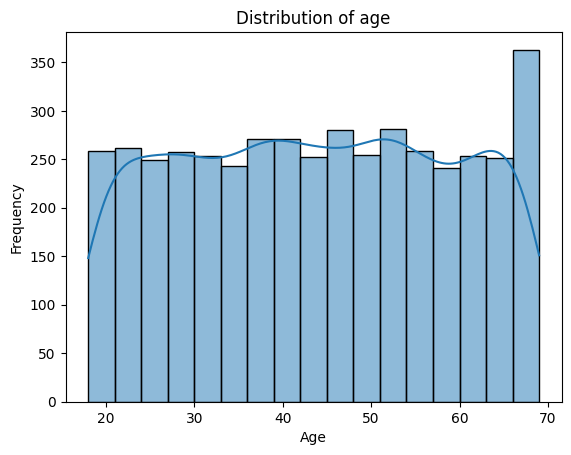

In [8]:
### Check distribution is normal distribution or not
sns.histplot(data=df, kde=True, x=df['Age'].dropna())
plt.title("Distribution of age")
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Decision 
hence distribution is multimodel hence use knn or mice imputers

### KNN INputer vis scikit learn

In [9]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df['Age'] = imputer.fit_transform(df[['Age']])

In [10]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
df.isna().sum()

Customer_ID                 0
Age                         0
Gender                      0
Region                      0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64

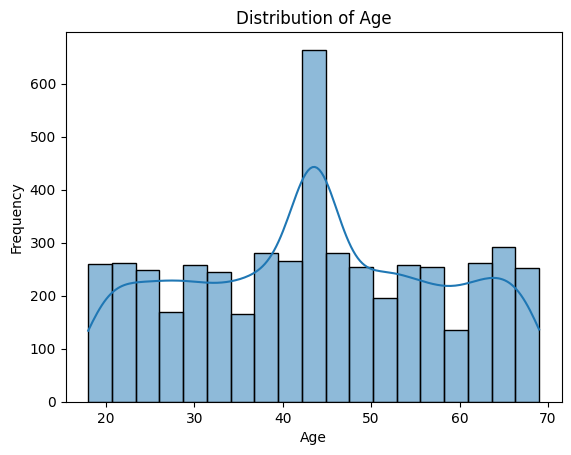

In [12]:
sns.histplot(data=df,kde=True,x=df['Age'])
plt.title("Distribution of Age")
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Using Mice imputer

In [13]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer()
df[['Age']] = imputer.fit_transform(df[['Age']])

### Data Cleaning
.Remove typos, duplicates, inconsistencies from data

In [18]:
df.sample(5)

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
1194,CUST001195,25.0,Female,West,2,6.0,13.58,93,48.01,0
2490,CUST002491,59.0,Male,East,3,2.0,13.48,356,39.10,1
766,CUST000767,55.0,Female,South,4,2.0,18.28,193,37.44,1
4530,CUST004531,21.0,Male,South,2,1.0,9.28,298,30.96,1
1969,CUST001970,23.0,Female,North,1,1.0,8.01,98,39.65,1


In [19]:
df['Gender'].value_counts()

Gender
Female    2514
Male      2486
Name: count, dtype: int64

In [20]:
df['Region'].value_counts()

Region
West     1316
North    1243
South    1239
East     1202
Name: count, dtype: int64

In [21]:
df.describe()

,Age,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
count,5000.000000,5000.000000,4500.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.582222,2.037000,5.54600,12.458404,181.441400,46.619784,0.448000
std,14.201213,1.422405,2.86929,4.325381,104.500951,9.522140,0.497338
min,18.000000,0.000000,1.00000,5.000000,1.000000,-5.060000,0.000000
25%,32.000000,1.000000,3.00000,8.700000,90.000000,39.897500,0.000000
50%,43.582222,2.000000,6.00000,12.500000,182.000000,46.625000,0.000000
75%,55.000000,3.000000,8.00000,16.190000,271.000000,53.210000,1.000000
max,69.000000,9.000000,10.00000,20.000000,364.000000,137.310000,1.000000


In [22]:
df[df['Monthly_Spend'] > 0]['Monthly_Spend'].min()

np.float64(21.77)

In [23]:
min_monthly_spend = df[df['Monthly_Spend'] > 0]['Monthly_Spend'].min()
df['Monthly_Spend'] = np.where(df['Monthly_Spend'] < 0, min_monthly_spend, df['Monthly_Spend'])


In [24]:
df.describe()

,Age,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
count,5000.000000,5000.000000,4500.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.582222,2.037000,5.54600,12.458404,181.441400,46.630208,0.448000
std,14.201213,1.422405,2.86929,4.325381,104.500951,9.480555,0.497338
min,18.000000,0.000000,1.00000,5.000000,1.000000,21.770000,0.000000
25%,32.000000,1.000000,3.00000,8.700000,90.000000,39.897500,0.000000
50%,43.582222,2.000000,6.00000,12.500000,182.000000,46.625000,0.000000
75%,55.000000,3.000000,8.00000,16.190000,271.000000,53.210000,1.000000
max,69.000000,9.000000,10.00000,20.000000,364.000000,137.310000,1.000000


## Detect Outliers

In [25]:
df.head()

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,South,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,East,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,East,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,West,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,East,2,NaN,13.18,65,45.97,0


In [26]:
df['Discount_Offered'].describe()

count    5000.000000
mean       12.458404
std         4.325381
min         5.000000
25%         8.700000
50%        12.500000
75%        16.190000
max        20.000000
Name: Discount_Offered, dtype: float64

<Axes: xlabel='Discount_Offered', ylabel='Density'>

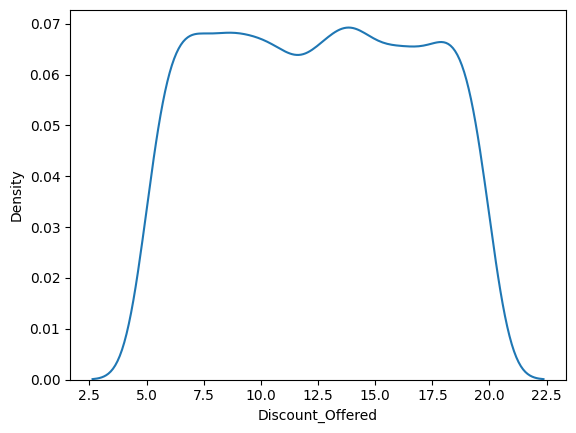

In [27]:
sns.kdeplot(x=df['Discount_Offered'], data= df)

In [28]:
df['Monthly_Spend'].describe()

count    5000.000000
mean       46.630208
std         9.480555
min        21.770000
25%        39.897500
50%        46.625000
75%        53.210000
max       137.310000
Name: Monthly_Spend, dtype: float64

<Axes: xlabel='Monthly_Spend', ylabel='Density'>

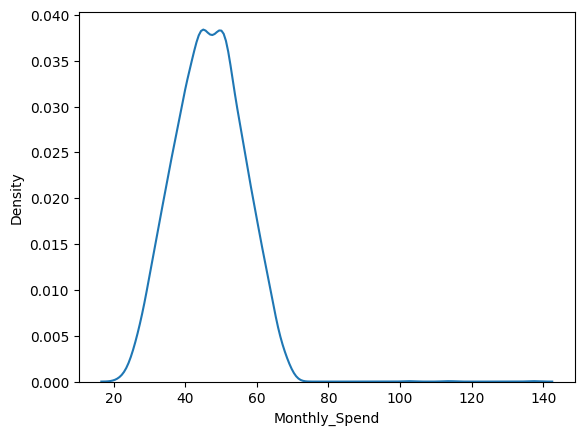

In [29]:
sns.kdeplot(data=df, x=df["Monthly_Spend"])

In [30]:
df[df['Monthly_Spend'] > 75]

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
1935,CUST001936,43.0,Male,South,1,1.0,6.00,135,102.44,1
2784,CUST002785,26.0,Male,East,1,10.0,13.03,69,137.31,0
4888,CUST004889,47.0,Female,South,4,8.0,5.16,96,113.66,0


In [32]:
mean = df['Monthly_Spend'].mean()
std = df['Monthly_Spend'].std()

upper_bound = mean + 3*std
lower_bound = mean - 3*std

within_3rd_std = df[(df['Monthly_Spend'] >= lower_bound) & (df['Monthly_Spend'] <= upper_bound)]

# count and percentage 
count_within = within_3rd_std.shape[0]
total_count = df.shape[0]

percentage = (count_within / total_count) * 100

percentage

99.94

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

month_spend_scaled = scaler.fit_transform(df[['Monthly_Spend']])

mask = np.abs(month_spend_scaled) < 3

df = df[mask.flatten()]

In [34]:
df[df['Monthly_Spend'] > 75]

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned


<Axes: xlabel='Monthly_Spend', ylabel='Density'>

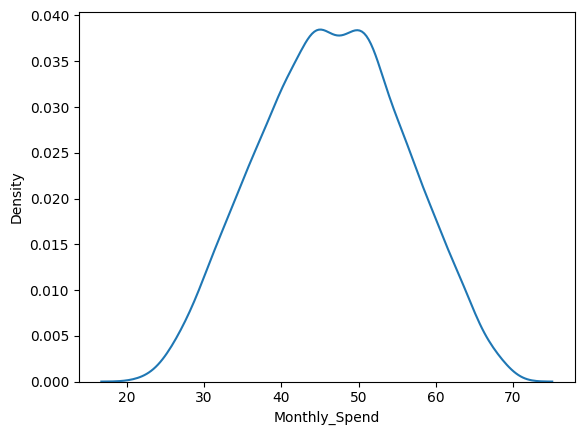

In [35]:
sns.kdeplot(x=df['Monthly_Spend'],data=df)